# Impact decay, pre-trends, and persistent order flow

This notebook asks whether the response observed inside an imbalance bar is
subsequently reversed, retained, or extended. It also tests whether prices
were already moving in the direction of the bar's imbalance before the bar
began. The latter is essential because a contemporaneous association between
return and imbalance can arise partly when order flow follows an existing
price movement.

The analysis uses the two primary constructions:

- continuous 4,000-event bars, for which a horizon is measured in market-event
  time and has variable clock duration; and
- five-minute bars, for which a horizon has fixed clock duration but contains
  a variable number of events.

The notebook estimates conditional trajectories rather than a causal impulse
response. Post-bar reversal is consistent with a transient liquidity
component; persistence is consistent with information incorporation; and
continuation may reflect persistent order flow, information, or momentum.

In [44]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
default_project = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
PROJECT_DIR = Path(os.environ.get('CRYPTO_IMPACT_PROJECT_DIR', default_project)).resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.crypto_impact.impact import add_trailing_impact_normalisation
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars,
    load_monthly_trades,
    make_time_bars,
)
from src.crypto_impact.regime_analysis import build_analysis_table

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

In [45]:
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'BTCUSDT_monthly'
FIGURE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_FIGURE_DIR', PROJECT_DIR / 'reports' / 'figures')
)
TABLE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_TABLE_DIR', PROJECT_DIR / 'reports' / 'tables')
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_PER_BAR = int(os.environ.get('CRYPTO_IMPACT_EVENTS_PER_BAR', '4000'))
TIME_WINDOW = '5min'
TRAILING_WINDOW = '1D'
MIN_TRAILING_BARS = 100
POST_HORIZONS = (1, 2, 3, 5, 10, 20)
PRE_HORIZONS = (1, 2, 3, 5, 10, 20)
STATE_QUANTILE = 0.80
SENSITIVITY_QUANTILE = 0.90
N_BOOTSTRAP = int(os.environ.get('CRYPTO_IMPACT_N_BOOTSTRAP', '500'))
MAX_FILES_ENV = int(os.environ.get('CRYPTO_IMPACT_MAX_FILES', '0'))
MAX_FILES = MAX_FILES_ENV or None
RANDOM_SEED = 20260902

OUTPUT_STEM = f'impact_decay_lead_lag_{EVENTS_PER_BAR}_event'

files = sorted(DATA_DIR.glob('BTCUSDT-trades-*.parquet'))
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No monthly parquet files found in {DATA_DIR}')
print(f'Event bars: {EVENTS_PER_BAR:,} events')
print(f'Files selected: {len(files)} ({files[0].name} to {files[-1].name})')

Event bars: 4,000 events
Files selected: 17 (BTCUSDT-trades-2025-01.parquet to BTCUSDT-trades-2026-05.parquet)


## Definitions

Let $s_t=\operatorname{sign}(Q_t)$ be the direction of the conditioning
bar's imbalance. Contemporaneous normalized impact is

$$
I_t(0)=\frac{s_t r_t}{\sigma^-_t}.
$$

The cumulative post-bar response and total response at horizon $h$ are

$$
F_t(h)=\frac{s_t\log(P_{t+h}/P_t)}{\sigma^-_t},
\qquad I_t(h)=I_t(0)+F_t(h).
$$

Within a state $g$, the fraction of mean impact remaining is

$$
\rho_g(h)=\frac{E[I_t(h)\mid g]}{E[I_t(0)\mid g]}.
$$

It is a ratio of conditional means, not a mean of observation-level ratios.
Values below one denote partial reversal, values near one denote persistence,
and values above one denote continuation.

The pre-bar trend over $k$ bars is

$$
B_t(k)=\frac{s_t\log(S_t/S_{t-k})}{\sigma^-_t},
$$

where $S_t$ is the start price of the conditioning bar. Positive $B_t(k)$
means that price was already moving in the eventual imbalance direction.

## Construct continuous event and time bars

Time bars are first constructed month by month and then concatenated before
leads and lags are calculated. Event bars use the existing continuous builder,
which carries incomplete event groups across month boundaries.

In [46]:
def construct_time_bars(paths, window=TIME_WINDOW):
    frames = []
    for path in paths:
        monthly = make_time_bars(load_monthly_trades(path), window=window)
        monthly['start_time'] = monthly.index
        monthly['end_time'] = monthly.index + pd.Timedelta(window)
        monthly['duration_seconds'] = pd.Timedelta(window).total_seconds()
        monthly['source_file'] = path.name
        frames.append(monthly)
    bars = pd.concat(frames).sort_index()
    if not bars.index.is_unique:
        raise ValueError('Five-minute bar start times are not unique.')
    return bars


event_bars = build_fixed_event_bars(files, events_per_bar=EVENTS_PER_BAR)
event_bars['start_time'] = event_bars.index
time_bars = construct_time_bars(files)

bar_samples = {
    'event_bars': event_bars,
    'time_bars': time_bars,
}

pd.DataFrame({
    name: {
        'bars': len(bars),
        'start': bars['start_time'].min(),
        'end': bars['end_time'].max(),
        'median_duration_seconds': bars['duration_seconds'].median(),
        'median_events': bars['trade_count'].median(),
    }
    for name, bars in bar_samples.items()
}).T

,bars,start,end,median_duration_seconds,median_events
event_bars,114804,2025-01-01 00:00:00.051000+00:00,2026-05-31 23:51:00.820000+00:00,313.042500,"4,000.000000"
time_bars,148605,2025-01-01 00:00:00+00:00,2026-06-01 00:00:00+00:00,300.000000,"2,155.000000"


## Add leads, lags, normalization, and persistent-flow measures

All lead and lag variables are signed by the conditioning bar's imbalance.
Future order flow is reported separately from the primary response estimate:
it is an outcome after the conditioning bar and therefore must not be treated
as an ordinary control. For horizon $h$ it is

$$
\Phi_t(h)=s_t\frac{\sum_{j=1}^hQ_{t+j}}
                        {\sum_{j=1}^hV_{t+j}},
$$

which is positive when subsequent net flow continues in the conditioning
direction and negative when it reverses.

In [47]:
def add_trajectory_variables(bars):
    analysis = build_analysis_table(bars, horizons=POST_HORIZONS)
    analysis = add_trailing_impact_normalisation(
        analysis,
        window=TRAILING_WINDOW,
        min_periods=MIN_TRAILING_BARS,
        timestamp_col='end_time',
    ).replace([np.inf, -np.inf], np.nan)

    direction = np.sign(analysis['signed_imbalance'])
    volatility = analysis['trailing_realised_volatility_bps']
    analysis['block_day'] = pd.to_datetime(
        analysis['end_time'], utc=True
    ).dt.floor('D')
    analysis['event_intensity'] = (
        analysis['trade_count'] / analysis['duration_seconds']
    )

    for horizon in POST_HORIZONS:
        signed_future = analysis[f'signed_future_return_{horizon}_bps']
        analysis[f'normalised_post_response_{horizon}'] = (
            signed_future / volatility
        )
        analysis[f'normalised_total_impact_{horizon}'] = (
            analysis['normalised_signed_impact']
            + analysis[f'normalised_post_response_{horizon}']
        )

        future_q = sum(
            analysis['signed_imbalance'].shift(-step)
            for step in range(1, horizon + 1)
        )
        future_volume = sum(
            analysis['gross_volume'].shift(-step)
            for step in range(1, horizon + 1)
        )
        analysis[f'future_flow_persistence_{horizon}'] = (
            direction * future_q / future_volume
        )
        analysis[f'elapsed_seconds_{horizon}'] = (
            pd.to_datetime(analysis['end_time'].shift(-horizon), utc=True)
            - pd.to_datetime(analysis['end_time'], utc=True)
        ).dt.total_seconds()

    analysis['normalised_total_impact_0'] = analysis['normalised_signed_impact']
    for lookback in PRE_HORIZONS:
        prior_return = 10_000 * np.log(
            analysis['start_price'] / analysis['start_price'].shift(lookback)
        )
        analysis[f'normalised_pretrend_{lookback}'] = (
            direction * prior_return / volatility
        )

    analysis['aligned_lagged_imbalance'] = (
        direction * analysis['signed_imbalance'].shift(1)
        / analysis['trailing_market_volume']
    )
    return analysis.replace([np.inf, -np.inf], np.nan)


analysis_samples = {
    name: add_trajectory_variables(bars)
    for name, bars in bar_samples.items()
}

## Four ex-ante states

The main grouping uses the upper quintile of activity and normalized
imbalance. Thresholds are estimated independently within each construction.
This produces four readily interpretable states without using fitted response
parameters to define the sample:

1. ordinary activity, ordinary imbalance;
2. high activity, ordinary imbalance;
3. ordinary activity, extreme imbalance; and
4. high activity, extreme imbalance.

A top-decile definition is reported later as a sensitivity check.

In [48]:
STATE_ORDER = [
    'ordinary_activity__ordinary_imbalance',
    'high_activity__ordinary_imbalance',
    'ordinary_activity__extreme_imbalance',
    'high_activity__extreme_imbalance',
]
STATE_LABELS = {
    'ordinary_activity__ordinary_imbalance': 'Ordinary activity / ordinary imbalance',
    'high_activity__ordinary_imbalance': 'High activity / ordinary imbalance',
    'ordinary_activity__extreme_imbalance': 'Ordinary activity / extreme imbalance',
    'high_activity__extreme_imbalance': 'High activity / extreme imbalance',
}
STATE_COLOURS = {
    'ordinary_activity__ordinary_imbalance': '#666666',
    'high_activity__ordinary_imbalance': '#56B4E9',
    'ordinary_activity__extreme_imbalance': '#E69F00',
    'high_activity__extreme_imbalance': '#D55E00',
}


def assign_states(data, quantile=STATE_QUANTILE):
    result = data.copy()
    valid = result[[
        'normalised_imbalance', 'event_intensity'
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    valid = valid.loc[
        (valid['normalised_imbalance'] > 0)
        & (valid['event_intensity'] > 0)
    ]
    x_med = float(valid['normalised_imbalance'].median())
    intensity_med = float(valid['event_intensity'].median())
    result['imbalance_u'] = result['normalised_imbalance'] / x_med
    result['activity_z'] = np.log(result['event_intensity'] / intensity_med)
    activity_threshold = float(result['activity_z'].quantile(quantile))
    imbalance_threshold = float(result['imbalance_u'].quantile(quantile))
    result['high_activity'] = result['activity_z'] >= activity_threshold
    result['extreme_imbalance'] = result['imbalance_u'] >= imbalance_threshold
    result['state'] = np.select(
        [
            ~result['high_activity'] & ~result['extreme_imbalance'],
            result['high_activity'] & ~result['extreme_imbalance'],
            ~result['high_activity'] & result['extreme_imbalance'],
            result['high_activity'] & result['extreme_imbalance'],
        ],
        STATE_ORDER,
        default=None,
    )
    return result, {
        'quantile': quantile,
        'x_med': x_med,
        'event_intensity_median': intensity_med,
        'activity_threshold_z': activity_threshold,
        'activity_threshold_multiple': np.exp(activity_threshold),
        'imbalance_threshold_u': imbalance_threshold,
    }


state_samples = {}
threshold_rows = []
for construction, sample in analysis_samples.items():
    state_sample, thresholds = assign_states(sample)
    state_samples[construction] = state_sample
    threshold_rows.append({'construction': construction, **thresholds})
state_thresholds = pd.DataFrame(threshold_rows)
state_thresholds

,construction,quantile,x_med,event_intensity_median,activity_threshold_z,activity_threshold_multiple,imbalance_threshold_u
0,event_bars,0.800000,0.000540,13.085601,0.845215,2.328479,2.428892
1,time_bars,0.800000,0.000358,7.186667,0.625512,1.869202,2.731440


In [49]:
sample_summary = pd.DataFrame([
    {
        'construction': construction,
        'observations': len(sample),
        'complete_current_impact': sample['normalised_signed_impact'].notna().sum(),
        'UTC_days': sample['block_day'].nunique(),
        **{
            f'n_{state}': int((sample['state'] == state).sum())
            for state in STATE_ORDER
        },
    }
    for construction, sample in state_samples.items()
])
sample_summary

,construction,observations,complete_current_impact,UTC_days,n_ordinary_activity__ordinary_imbalance,n_high_activity__ordinary_imbalance,n_ordinary_activity__extreme_imbalance,n_high_activity__extreme_imbalance
0,event_bars,114804,111576,516,75361,17127,16482,5834
1,time_bars,148605,148505,517,102403,16501,16479,13222


## Clock-time mapping of event horizons

Event-bar horizons are not durations. The following table records their
realized clock-time distribution. This must accompany any comparison with
the exactly spaced five-minute construction.

In [50]:
clock_time_rows = []
for construction, sample in state_samples.items():
    for horizon in POST_HORIZONS:
        elapsed = sample[f'elapsed_seconds_{horizon}'].dropna() / 60.0
        clock_time_rows.append({
            'construction': construction,
            'horizon_bars': horizon,
            'p10_elapsed_minutes': elapsed.quantile(0.10),
            'median_elapsed_minutes': elapsed.median(),
            'p90_elapsed_minutes': elapsed.quantile(0.90),
        })
clock_time_mapping = pd.DataFrame(clock_time_rows)
clock_time_mapping

,construction,horizon_bars,p10_elapsed_minutes,median_elapsed_minutes,p90_elapsed_minutes
0,event_bars,1,1.386060,5.219417,13.227837
1,event_bars,2,2.898490,10.625308,26.075900
2,event_bars,3,4.482017,16.096417,38.751933
3,event_bars,5,7.798413,27.180117,63.611330
4,event_bars,10,16.657948,55.387950,124.533605
5,event_bars,20,36.406747,112.710000,242.927905
6,time_bars,1,5.000000,5.000000,5.000000
7,time_bars,2,10.000000,10.000000,10.000000
8,time_bars,3,15.000000,15.000000,15.000000
9,time_bars,5,25.000000,25.000000,25.000000


## Cluster bootstrap

Complete UTC days are the resampling blocks. Lead and lag outcomes are
constructed before resampling, so duplicated days do not create artificial
transitions. The same sampled days are used for all states and horizons in a
bootstrap draw, preserving covariance for state contrasts.

In [51]:
def _daily_paired_totals(data, outcome_col, baseline_col, group_col='state'):
    if outcome_col == baseline_col:
        sample = data[[
            'block_day', group_col, outcome_col
        ]].replace([np.inf, -np.inf], np.nan).dropna()
        daily = (
            sample.groupby(['block_day', group_col], observed=True)[outcome_col]
            .agg(outcome_sum='sum', count='count')
            .reset_index()
        )
        daily['baseline_sum'] = daily['outcome_sum']
        return daily
    sample = data[[
        'block_day', group_col, outcome_col, baseline_col
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    return (
        sample.groupby(['block_day', group_col], observed=True)
        .agg(
            outcome_sum=(outcome_col, 'sum'),
            baseline_sum=(baseline_col, 'sum'),
            count=(outcome_col, 'count'),
        )
        .reset_index()
    )


def bootstrap_retention(data, n_bootstrap=N_BOOTSTRAP, random_state=0):
    days = np.asarray(sorted(data['block_day'].dropna().unique()))
    rng = np.random.default_rng(random_state)
    summary_rows = []
    draw_rows = []
    for horizon in (0, *POST_HORIZONS):
        outcome_col = f'normalised_total_impact_{horizon}'
        daily = _daily_paired_totals(
            data, outcome_col, 'normalised_total_impact_0'
        )
        point = daily.groupby('state', observed=True)[[
            'outcome_sum', 'baseline_sum', 'count'
        ]].sum()
        point['mean_total_impact'] = point['outcome_sum'] / point['count']
        point['mean_initial_impact'] = point['baseline_sum'] / point['count']
        point['fraction_remaining'] = (
            point['mean_total_impact'] / point['mean_initial_impact']
        )

        by_day = {
            day: group.set_index('state')
            for day, group in daily.groupby('block_day', observed=True)
        }
        horizon_draws = {state: [] for state in STATE_ORDER}
        for draw_number in range(n_bootstrap):
            sampled_days = rng.choice(days, size=len(days), replace=True)
            combined = pd.concat(
                [by_day[day] for day in sampled_days if day in by_day]
            )
            totals = combined.groupby(level=0)[[
                'outcome_sum', 'baseline_sum', 'count'
            ]].sum()
            for state in STATE_ORDER:
                if state not in totals.index:
                    continue
                row = totals.loc[state]
                fraction = row['outcome_sum'] / row['baseline_sum']
                horizon_draws[state].append(fraction)
                draw_rows.append({
                    'bootstrap_sample': draw_number,
                    'state': state,
                    'horizon': horizon,
                    'fraction_remaining': fraction,
                })
        for state in STATE_ORDER:
            if state not in point.index:
                continue
            values = pd.Series(horizon_draws[state], dtype=float)
            summary_rows.append({
                'state': state,
                'horizon': horizon,
                'count': int(point.loc[state, 'count']),
                'mean_initial_impact': point.loc[state, 'mean_initial_impact'],
                'mean_total_impact': point.loc[state, 'mean_total_impact'],
                'fraction_remaining': point.loc[state, 'fraction_remaining'],
                'fraction_remaining_p025': values.quantile(0.025),
                'fraction_remaining_p975': values.quantile(0.975),
            })
    return pd.DataFrame(summary_rows), pd.DataFrame(draw_rows)


def bootstrap_group_means(
    data, horizon_to_column, value_name, n_bootstrap=N_BOOTSTRAP,
    random_state=0,
):
    days = np.asarray(sorted(data['block_day'].dropna().unique()))
    rng = np.random.default_rng(random_state)
    rows = []
    for horizon, outcome_col in horizon_to_column.items():
        sample = data[[
            'block_day', 'state', outcome_col
        ]].replace([np.inf, -np.inf], np.nan).dropna()
        daily = (
            sample.groupby(['block_day', 'state'], observed=True)[outcome_col]
            .agg(value_sum='sum', count='count')
            .reset_index()
        )
        point = daily.groupby('state', observed=True)[[
            'value_sum', 'count'
        ]].sum()
        by_day = {
            day: group.set_index('state')
            for day, group in daily.groupby('block_day', observed=True)
        }
        draws = {state: [] for state in STATE_ORDER}
        for _ in range(n_bootstrap):
            sampled_days = rng.choice(days, size=len(days), replace=True)
            combined = pd.concat(
                [by_day[day] for day in sampled_days if day in by_day]
            )
            totals = combined.groupby(level=0)[['value_sum', 'count']].sum()
            for state in STATE_ORDER:
                if state in totals.index:
                    draws[state].append(
                        totals.loc[state, 'value_sum'] / totals.loc[state, 'count']
                    )
        for state in STATE_ORDER:
            if state not in point.index:
                continue
            values = pd.Series(draws[state], dtype=float)
            estimate = point.loc[state, 'value_sum'] / point.loc[state, 'count']
            rows.append({
                'state': state,
                'horizon': horizon,
                'count': int(point.loc[state, 'count']),
                value_name: estimate,
                f'{value_name}_p025': values.quantile(0.025),
                f'{value_name}_p975': values.quantile(0.975),
            })
    return pd.DataFrame(rows)


trajectory_frames = []
trajectory_draw_frames = []
pretrend_frames = []
flow_frames = []
for construction_number, (construction, sample) in enumerate(state_samples.items()):
    trajectory, draws = bootstrap_retention(
        sample,
        random_state=RANDOM_SEED + construction_number * 10_000,
    )
    pretrend = bootstrap_group_means(
        sample,
        {h: f'normalised_pretrend_{h}' for h in PRE_HORIZONS},
        'mean_normalised_pretrend',
        random_state=RANDOM_SEED + 2_000 + construction_number * 10_000,
    )
    flow = bootstrap_group_means(
        sample,
        {h: f'future_flow_persistence_{h}' for h in POST_HORIZONS},
        'mean_future_flow_persistence',
        random_state=RANDOM_SEED + 4_000 + construction_number * 10_000,
    )
    for frame in (trajectory, draws, pretrend, flow):
        frame.insert(0, 'construction', construction)
    trajectory_frames.append(trajectory)
    trajectory_draw_frames.append(draws)
    pretrend_frames.append(pretrend)
    flow_frames.append(flow)

trajectory_summary = pd.concat(trajectory_frames, ignore_index=True)
trajectory_bootstrap = pd.concat(trajectory_draw_frames, ignore_index=True)
pretrend_summary = pd.concat(pretrend_frames, ignore_index=True)
future_flow_summary = pd.concat(flow_frames, ignore_index=True)
trajectory_summary

,construction,state,horizon,count,mean_initial_impact,mean_total_impact,fraction_remaining,fraction_remaining_p025,fraction_remaining_p975
0,event_bars,ordinary_activity__ordinary_imbalance,0,72271,0.026792,0.026792,1.000000,1.000000,1.000000
1,event_bars,high_activity__ordinary_imbalance,0,16989,0.029955,0.029955,1.000000,1.000000,1.000000
2,event_bars,ordinary_activity__extreme_imbalance,0,16482,0.080298,0.080298,1.000000,1.000000,1.000000
3,event_bars,high_activity__extreme_imbalance,0,5834,0.089053,0.089053,1.000000,1.000000,1.000000
4,event_bars,ordinary_activity__ordinary_imbalance,1,72271,0.026792,0.025939,0.968189,0.950688,0.988409
5,event_bars,high_activity__ordinary_imbalance,1,16989,0.029955,0.029210,0.975128,0.943486,1.008202
6,event_bars,ordinary_activity__extreme_imbalance,1,16482,0.080298,0.078858,0.982062,0.967055,0.997442
7,event_bars,high_activity__extreme_imbalance,1,5834,0.089053,0.087464,0.982152,0.961111,1.004680
8,event_bars,ordinary_activity__ordinary_imbalance,2,72271,0.026792,0.025720,0.959990,0.934117,0.984864
9,event_bars,high_activity__ordinary_imbalance,2,16989,0.029955,0.028761,0.960167,0.920215,1.003255


## Main lead-lag and decay figure

The top row shows the fraction of mean contemporaneous impact remaining after
each horizon. The bottom row shows cumulative price movement before the
conditioning bar, signed by its eventual imbalance. Positive pre-trends are
consistent with momentum selection. Confidence bands are UTC-day block
bootstrap intervals.

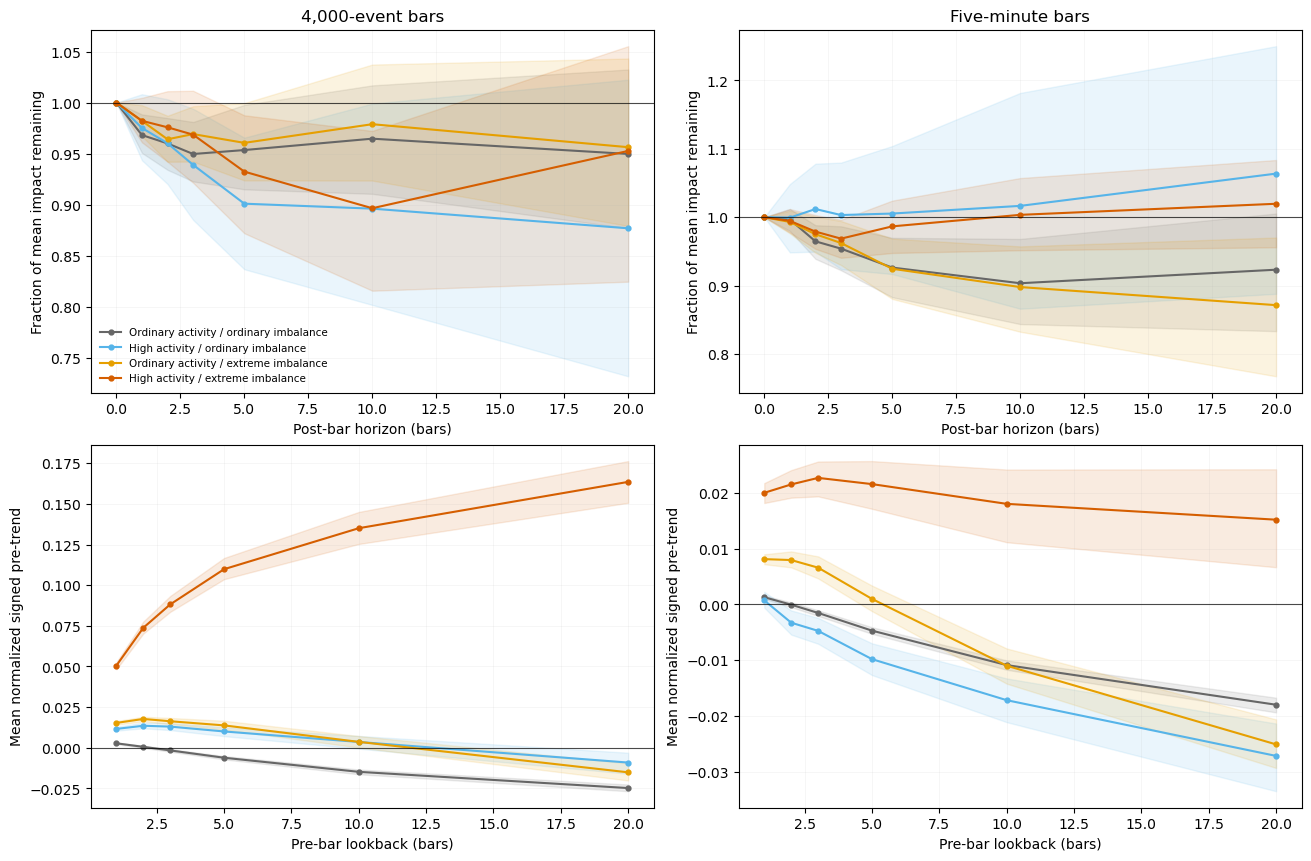

In [52]:
fig, axes = plt.subplots(
    2, 2, figsize=(13.0, 8.5), constrained_layout=True,
)
for column, construction in enumerate(['event_bars', 'time_bars']):
    decay_ax = axes[0, column]
    pre_ax = axes[1, column]
    for state in STATE_ORDER:
        decay = trajectory_summary.loc[
            (trajectory_summary['construction'] == construction)
            & (trajectory_summary['state'] == state)
        ].sort_values('horizon')
        pre = pretrend_summary.loc[
            (pretrend_summary['construction'] == construction)
            & (pretrend_summary['state'] == state)
        ].sort_values('horizon')
        colour = STATE_COLOURS[state]
        decay_ax.plot(
            decay['horizon'], decay['fraction_remaining'], marker='o',
            ms=3.5, lw=1.5, color=colour, label=STATE_LABELS[state],
        )
        decay_ax.fill_between(
            decay['horizon'], decay['fraction_remaining_p025'],
            decay['fraction_remaining_p975'], color=colour, alpha=0.12,
        )
        pre_ax.plot(
            pre['horizon'], pre['mean_normalised_pretrend'], marker='o',
            ms=3.5, lw=1.5, color=colour,
        )
        pre_ax.fill_between(
            pre['horizon'], pre['mean_normalised_pretrend_p025'],
            pre['mean_normalised_pretrend_p975'], color=colour, alpha=0.12,
        )
    title = (
        f'{EVENTS_PER_BAR:,}-event bars'
        if construction == 'event_bars' else 'Five-minute bars'
    )
    decay_ax.set_title(title)
    decay_ax.axhline(1.0, color='black', lw=0.8, alpha=0.7)
    decay_ax.set_xlabel('Post-bar horizon (bars)')
    decay_ax.set_ylabel('Fraction of mean impact remaining')
    decay_ax.grid(alpha=0.15, linewidth=0.5)
    pre_ax.axhline(0.0, color='black', lw=0.8, alpha=0.7)
    pre_ax.set_xlabel('Pre-bar lookback (bars)')
    pre_ax.set_ylabel('Mean normalized signed pre-trend')
    pre_ax.grid(alpha=0.15, linewidth=0.5)

axes[0, 0].legend(frameon=False, fontsize=7.5)
figure_path = FIGURE_DIR / f'21_{OUTPUT_STEM}_trajectories.pdf'
fig.savefig(figure_path, bbox_inches='tight')
plt.show()

## High-activity/extreme-imbalance contrasts

The contrast below subtracts the ordinary/ordinary retention fraction from
the high-activity/extreme-imbalance fraction. A negative contrast means that
the joint stress state reverses more strongly. Confidence intervals use
paired bootstrap draws, so common day effects cancel where possible.

In [53]:
contrast_rows = []
for construction in ['event_bars', 'time_bars']:
    construction_draws = trajectory_bootstrap.loc[
        trajectory_bootstrap['construction'] == construction
    ]
    for horizon in (0, *POST_HORIZONS):
        pivot = construction_draws.loc[
            construction_draws['horizon'] == horizon
        ].pivot(
            index='bootstrap_sample', columns='state',
            values='fraction_remaining',
        ).dropna(subset=[
            'high_activity__extreme_imbalance',
            'ordinary_activity__ordinary_imbalance',
        ])
        values = (
            pivot['high_activity__extreme_imbalance']
            - pivot['ordinary_activity__ordinary_imbalance']
        )
        point = trajectory_summary.loc[
            (trajectory_summary['construction'] == construction)
            & (trajectory_summary['horizon'] == horizon)
        ].set_index('state')['fraction_remaining']
        contrast_rows.append({
            'construction': construction,
            'horizon': horizon,
            'high_extreme_minus_ordinary_retention': (
                point['high_activity__extreme_imbalance']
                - point['ordinary_activity__ordinary_imbalance']
            ),
            'contrast_p025': values.quantile(0.025),
            'contrast_p975': values.quantile(0.975),
            'bootstrap_probability_negative': (values < 0).mean(),
        })
state_contrasts = pd.DataFrame(contrast_rows)
state_contrasts

,construction,horizon,high_extreme_minus_ordinary_retention,contrast_p025,contrast_p975,bootstrap_probability_negative
0,event_bars,0,0.000000,0.000000,0.000000,0.000000
1,event_bars,1,0.013963,-0.017421,0.042343,0.176000
2,event_bars,2,0.015798,-0.030322,0.058367,0.250000
3,event_bars,3,0.018944,-0.037839,0.069722,0.320000
4,event_bars,5,-0.021130,-0.088051,0.049247,0.706000
5,event_bars,10,-0.068151,-0.168200,0.044866,0.900000
6,event_bars,20,0.002957,-0.130272,0.142863,0.494000
7,time_bars,0,0.000000,0.000000,0.000000,0.000000
8,time_bars,1,-0.001982,-0.024656,0.020579,0.540000
9,time_bars,2,0.014196,-0.018855,0.047708,0.242000


## Momentum-adjusted descriptive regressions

These regressions do not identify causal impact. They ask whether the joint
high-activity/extreme-imbalance state remains associated with concurrent and
subsequent signed returns after controlling for two non-overlapping pre-trend
intervals and lagged aligned imbalance. Standard errors are clustered by UTC
day. Future order flow is deliberately excluded because it occurs after the
conditioning observation.

In [54]:
def fit_momentum_adjusted_regressions(data):
    prepared = data.copy()
    prepared['joint_high_extreme'] = (
        prepared['high_activity'] & prepared['extreme_imbalance']
    ).astype(float)
    prepared['high_activity_indicator'] = prepared['high_activity'].astype(float)
    prepared['extreme_imbalance_indicator'] = prepared['extreme_imbalance'].astype(float)
    prepared['pretrend_2_to_5'] = (
        prepared['normalised_pretrend_5']
        - prepared['normalised_pretrend_1']
    )
    targets = {
        0: 'normalised_signed_impact',
        **{
            horizon: f'normalised_post_response_{horizon}'
            for horizon in POST_HORIZONS
        },
    }
    predictors = [
        'high_activity_indicator',
        'extreme_imbalance_indicator',
        'joint_high_extreme',
        'normalised_pretrend_1',
        'pretrend_2_to_5',
        'aligned_lagged_imbalance',
    ]
    rows = []
    for horizon, target in targets.items():
        sample = prepared[[target, 'block_day', *predictors]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        design = sample[predictors].astype(float).copy()
        for control in [
            'normalised_pretrend_1', 'pretrend_2_to_5',
            'aligned_lagged_imbalance',
        ]:
            scale = design[control].std(ddof=1)
            if not np.isfinite(scale) or scale <= 0:
                raise ValueError(f'Cannot standardize {control}.')
            design[control] = (design[control] - design[control].mean()) / scale
        design = sm.add_constant(design, has_constant='add')
        fitted = sm.OLS(sample[target], design).fit(
            cov_type='cluster', cov_kwds={'groups': sample['block_day']}
        )
        coefficient = 'joint_high_extreme'
        rows.append({
            'horizon': horizon,
            'target': target,
            'observations': int(fitted.nobs),
            'UTC_day_clusters': sample['block_day'].nunique(),
            'joint_high_extreme_coefficient': fitted.params[coefficient],
            'standard_error': fitted.bse[coefficient],
            'p_value': fitted.pvalues[coefficient],
            'ci_low': fitted.conf_int().loc[coefficient, 0],
            'ci_high': fitted.conf_int().loc[coefficient, 1],
            'r_squared': fitted.rsquared,
        })
    return pd.DataFrame(rows)


regression_frames = []
for construction, sample in state_samples.items():
    results = fit_momentum_adjusted_regressions(sample)
    results.insert(0, 'construction', construction)
    regression_frames.append(results)
momentum_adjusted_regressions = pd.concat(regression_frames, ignore_index=True)
momentum_adjusted_regressions

,construction,horizon,target,observations,UTC_day_clusters,joint_high_extreme_coefficient,standard_error,p_value,ci_low,ci_high,r_squared
0,event_bars,0,normalised_signed_impact,111576,506,0.010049,0.001434,0.000000,0.007237,0.012860,0.180366
1,event_bars,1,normalised_post_response_1,111576,506,-0.000109,0.001344,0.935150,-0.002743,0.002524,0.000068
2,event_bars,2,normalised_post_response_2,111576,506,0.000948,0.001943,0.625803,-0.002861,0.004756,0.000057
3,event_bars,3,normalised_post_response_3,111576,506,0.000230,0.002358,0.922137,-0.004391,0.004852,0.000027
4,event_bars,5,normalised_post_response_5,111576,506,-0.001196,0.003028,0.692797,-0.007130,0.004738,0.000071
5,event_bars,10,normalised_post_response_10,111576,506,-0.005392,0.004285,0.208295,-0.013790,0.003007,0.000081
6,event_bars,20,normalised_post_response_20,111576,506,0.001349,0.006510,0.835840,-0.011410,0.014108,0.000028
7,time_bars,0,normalised_signed_impact,148505,517,0.033905,0.001129,0.000000,0.031692,0.036118,0.224403
8,time_bars,1,normalised_post_response_1,148504,516,0.000001,0.001249,0.999666,-0.002448,0.002449,0.000236
9,time_bars,2,normalised_post_response_2,148503,516,-0.001370,0.001723,0.426471,-0.004747,0.002007,0.000242


## Future-flow persistence

This is a mediation diagnostic rather than an impact control. Positive values
indicate that future net imbalance tends to continue in the original
direction. If price continuation and flow persistence appear together, the
former should not be attributed solely to a permanent response to the
conditioning bar.

In [55]:
future_flow_summary

,construction,state,horizon,count,mean_future_flow_persistence,mean_future_flow_persistence_p025,mean_future_flow_persistence_p975
0,event_bars,ordinary_activity__ordinary_imbalance,1,75360,0.022027,0.020402,0.023643
1,event_bars,high_activity__ordinary_imbalance,1,17127,0.028270,0.025047,0.031390
2,event_bars,ordinary_activity__extreme_imbalance,1,16482,0.049494,0.045932,0.053168
3,event_bars,high_activity__extreme_imbalance,1,5834,0.052001,0.045729,0.058054
4,event_bars,ordinary_activity__ordinary_imbalance,2,75359,0.015891,0.014484,0.017257
5,event_bars,high_activity__ordinary_imbalance,2,17127,0.020607,0.017987,0.023527
6,event_bars,ordinary_activity__extreme_imbalance,2,16482,0.036321,0.032495,0.039278
7,event_bars,high_activity__extreme_imbalance,2,5834,0.038196,0.033116,0.043638
8,event_bars,ordinary_activity__ordinary_imbalance,3,75358,0.012466,0.011249,0.013812
9,event_bars,high_activity__ordinary_imbalance,3,17127,0.016511,0.013762,0.019059


## Compact data summary accompanying the trajectory figure

The figure carries the complete paths and bootstrap bands. This table reports
selected points from the same estimates. Initial impact is included because
the retention curves are normalized to one at horizon zero and therefore hide
economically important differences in their starting levels.

In [56]:
SUMMARY_HORIZONS = (1, 5, 10, 20)

initial_summary = (
    trajectory_summary.loc[
        trajectory_summary['horizon'] == 0,
        ['construction', 'state', 'count', 'mean_initial_impact'],
    ]
    .rename(columns={'count': 'observations'})
)
retention_summary = (
    trajectory_summary.loc[
        trajectory_summary['horizon'].isin(SUMMARY_HORIZONS)
    ]
    .pivot(
        index=['construction', 'state'],
        columns='horizon',
        values='fraction_remaining',
    )
    .rename(columns=lambda horizon: f'retention_h{horizon}')
    .reset_index()
)
selected_pretrend_summary = (
    pretrend_summary.loc[
        pretrend_summary['horizon'].isin(SUMMARY_HORIZONS)
    ]
    .pivot(
        index=['construction', 'state'],
        columns='horizon',
        values='mean_normalised_pretrend',
    )
    .rename(columns=lambda horizon: f'pretrend_k{horizon}')
    .reset_index()
)
paper_figure_summary = (
    initial_summary
    .merge(retention_summary, on=['construction', 'state'], validate='one_to_one')
    .merge(
        selected_pretrend_summary,
        on=['construction', 'state'],
        validate='one_to_one',
    )
)
paper_figure_summary['state_label'] = paper_figure_summary['state'].map(STATE_LABELS)
paper_figure_summary['state_order'] = paper_figure_summary['state'].map(
    {state: position for position, state in enumerate(STATE_ORDER)}
)
paper_figure_summary = paper_figure_summary.sort_values(
    ['construction', 'state_order']
).drop(columns='state_order')
paper_figure_summary

,construction,state,observations,mean_initial_impact,retention_h1,retention_h5,retention_h10,retention_h20,pretrend_k1,pretrend_k5,pretrend_k10,pretrend_k20,state_label
0,event_bars,ordinary_activity__ordinary_imbalance,72271,0.026792,0.968189,0.953515,0.964653,0.949696,0.002705,-0.006180,-0.014847,-0.024833,Ordinary activity / ordinary imbalance
1,event_bars,high_activity__ordinary_imbalance,16989,0.029955,0.975128,0.900977,0.896114,0.876864,0.011568,0.009990,0.003530,-0.009145,High activity / ordinary imbalance
2,event_bars,ordinary_activity__extreme_imbalance,16482,0.080298,0.982062,0.960549,0.978839,0.956319,0.015254,0.013722,0.003585,-0.015157,Ordinary activity / extreme imbalance
3,event_bars,high_activity__extreme_imbalance,5834,0.089053,0.982152,0.932384,0.896502,0.952654,0.050504,0.109839,0.135050,0.163541,High activity / extreme imbalance
4,time_bars,ordinary_activity__ordinary_imbalance,102303,0.018296,0.996590,0.926360,0.903459,0.923236,0.001296,-0.004693,-0.010867,-0.017969,Ordinary activity / ordinary imbalance
5,time_bars,high_activity__ordinary_imbalance,16501,0.026202,0.999299,1.005310,1.016528,1.063680,0.000730,-0.009805,-0.017154,-0.027139,High activity / ordinary imbalance
6,time_bars,ordinary_activity__extreme_imbalance,16479,0.060657,0.993009,0.924589,0.897869,0.871438,0.008121,0.000989,-0.010979,-0.025076,Ordinary activity / extreme imbalance
7,time_bars,high_activity__extreme_imbalance,13222,0.101727,0.994608,0.986570,1.003423,1.019608,0.020004,0.021564,0.018026,0.015187,High activity / extreme imbalance


## Top-decile state sensitivity

The main upper-quintile definition balances tail relevance and precision.
The following point estimates repeat the principal retention calculation
using upper-decile activity and imbalance thresholds. They are deliberately
kept as a table rather than an additional figure.

In [57]:
def point_retention(data):
    rows = []
    for state, group in data.groupby('state', observed=True):
        for horizon in (0, *POST_HORIZONS):
            outcome_col = f'normalised_total_impact_{horizon}'
            if horizon == 0:
                sample = group[['normalised_total_impact_0']].dropna()
                initial = sample['normalised_total_impact_0'].mean()
                total = initial
            else:
                sample = group[[
                    'normalised_total_impact_0', outcome_col,
                ]].dropna()
                initial = sample['normalised_total_impact_0'].mean()
                total = sample[outcome_col].mean()
            rows.append({
                'state': state,
                'horizon': horizon,
                'count': len(sample),
                'fraction_remaining': total / initial,
            })
    return pd.DataFrame(rows)


sensitivity_frames = []
for construction, sample in analysis_samples.items():
    sensitivity_sample, sensitivity_thresholds = assign_states(
        sample, quantile=SENSITIVITY_QUANTILE
    )
    sensitivity = point_retention(sensitivity_sample)
    sensitivity.insert(0, 'state_quantile', SENSITIVITY_QUANTILE)
    sensitivity.insert(0, 'construction', construction)
    sensitivity_frames.append(sensitivity)
state_definition_sensitivity = pd.concat(sensitivity_frames, ignore_index=True)
state_definition_sensitivity.loc[
    state_definition_sensitivity['state'] == 'high_activity__extreme_imbalance'
]

,construction,state_quantile,state,horizon,count,fraction_remaining
0,event_bars,0.900000,high_activity__extreme_imbalance,0,1992,1.000000
1,event_bars,0.900000,high_activity__extreme_imbalance,1,1992,0.987269
2,event_bars,0.900000,high_activity__extreme_imbalance,2,1992,0.977882
3,event_bars,0.900000,high_activity__extreme_imbalance,3,1992,0.951877
4,event_bars,0.900000,high_activity__extreme_imbalance,5,1992,0.903630
5,event_bars,0.900000,high_activity__extreme_imbalance,10,1992,0.892409
6,event_bars,0.900000,high_activity__extreme_imbalance,20,1992,1.003171
28,time_bars,0.900000,high_activity__extreme_imbalance,0,5448,1.000000
29,time_bars,0.900000,high_activity__extreme_imbalance,1,5448,0.993910
30,time_bars,0.900000,high_activity__extreme_imbalance,2,5448,0.973583


## Save outputs

In [58]:
sample_summary.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_sample_summary.csv', index=False)
state_thresholds.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_state_thresholds.csv', index=False)
clock_time_mapping.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_clock_time_mapping.csv', index=False)
trajectory_summary.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_trajectory_summary.csv', index=False)
trajectory_bootstrap.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_trajectory_bootstrap.csv', index=False)
pretrend_summary.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_pretrend_summary.csv', index=False)
future_flow_summary.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_future_flow_summary.csv', index=False)
paper_figure_summary.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_paper_figure_summary.csv', index=False
)
state_contrasts.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_state_contrasts.csv', index=False)
momentum_adjusted_regressions.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_momentum_adjusted_regressions.csv', index=False
)
state_definition_sensitivity.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_state_definition_sensitivity.csv', index=False
)

print('Figure:', figure_path)
print('Tables:', TABLE_DIR / f'{OUTPUT_STEM}_*.csv')

Figure: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/21_impact_decay_lead_lag_4000_event_trajectories.pdf
Tables: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/tables/impact_decay_lead_lag_4000_event_*.csv


## Interpretation checklist

The analysis should be read in the following order.

1. **Pre-trend:** Is the signed price movement already positive before the
   conditioning bar? If so, momentum selection is present and the
   contemporaneous response cannot be interpreted as wholly initiated by the
   bar's imbalance.
2. **Decay:** Does the fraction remaining fall below one after the bar? A
   statistically meaningful reversal supports a transient component.
3. **Joint state:** Does decay differ specifically in the high-activity and
   extreme-imbalance state? This connects the dynamic result to the fitted
   effective-liquidity mechanism.
4. **Persistent flow:** Is subsequent net imbalance aligned with the original
   bar? Price continuation accompanied by continuing flow is not evidence of
   a permanent response to the conditioning bar alone.
5. **Construction:** Are the qualitative findings common to event and time
   bars after acknowledging their different clocks?
6. **Sensitivity:** Does the conclusion survive a narrower top-decile state?

Even a clean result does not identify order submissions and cancellations
separately. It distinguishes transient reversal, persistence, and continuation
in aggregate transaction-price responses and narrows—but does not eliminate—
the momentum and information interpretations.